# Parallel trends is an assumption, and the test for it has a power

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/diff-in-diff/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/diff-in-diff/demo.ipynb)

**Day 167 · `diff-in-diff` · Data Science Cookbook**

Difference-in-differences is the estimator you reach for when you could not randomise. It
is four means, and it is unbiased under exactly one assumption: that the treated group's
outcome *would have moved the same way as the control group's* if nothing had happened.
That counterfactual is unobservable, so the assumption is untestable — and the thing
everybody runs instead, the flat pre-trends plot, is a hypothesis test with a power.

This notebook measures what that power is worth, on worlds whose true treatment effect is
known to be **1.00**, so every gap below is a measurement rather than an argument.

### What it covers

| § | Question | The measured answer |
|---|----------|--------------------|
| 1 | Does more data help? | No. The bias is `δ × Δt` with no `n` in it; coverage goes 0.29 → 0.00 |
| 2 | What can the pre-trends test see? | A violation that biases the answer 30% fires the test 6% of the time |
| 3 | Does screening on it help? | It removes **none** of the bias, to within Monte Carlo error |
| 4 | What about the standard error? | Serial correlation makes a 0.05 test reject a true null 0.32 of the time |
| 5 | Isn't clustering the fix? | Only at the right **level** — 6 clusters done right beat 50 done too fine |
| 6 | And staggered adoption? | Every true effect positive, the estimate **negative** |
| 7 | Is there a fix? | Yes, and it is a `WHERE` clause: never use an already-treated unit as a control |
| 8 | Levels or logs? | Different assumptions. Same data, opposite sign. And this one *is* testable |

Everything runs on numpy and scipy. No data files, no API keys, no network.

## Step 1 — the engine, in about forty lines

A balanced panel is two `(N, T)` arrays: `Y` (outcome) and `D` (treated-and-post
indicator). For a *balanced* panel the two-way within transform is the **exact**
annihilator of unit and time fixed effects, which is what lets every closed form below
be checked to machine precision instead of approximately.

In [1]:
from __future__ import annotations


import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.color": "#dfe5ea", "axes.spines.top": False,
                     "axes.spines.right": False})
INK, MUTE, GOOD, BAD, WARN, COOL, PLUM = (
    "#16222e", "#8b9aa7", "#1f7a5c", "#b3402f", "#c98a1a", "#2b6ca3", "#6b4d8f")


def two_way_demean(X: np.ndarray) -> np.ndarray:
    """Residual of X on unit + time dummies.  Exact for a balanced panel."""
    return X - X.mean(axis=1, keepdims=True) - X.mean(axis=0, keepdims=True) + X.mean()


def did_2x2(Y, treated, pre, post) -> float:
    """The four-means estimator.  No regression, no options."""
    t = np.asarray(treated, dtype=bool)
    pre, post = list(pre), list(post)
    return float((Y[t][:, post].mean() - Y[t][:, pre].mean())
                 - (Y[~t][:, post].mean() - Y[~t][:, pre].mean()))


def twfe(Y: np.ndarray, D: np.ndarray) -> float:
    """Two-way fixed effects coefficient on the treatment dummy."""
    Dt = two_way_demean(D)
    return float((Dt * Y).sum() / (Dt * Dt).sum())


def twfe_cell_weights(D: np.ndarray) -> np.ndarray:
    """Weight TWFE puts on each treated cell's OWN effect.  Sums to 1; not all positive."""
    Dt = two_way_demean(D)
    return np.where(D > 0, Dt / (Dt * Dt).sum(), 0.0)


def fe_ols(Y, regressors, vcov="cluster", cluster_id=None):
    """OLS with unit and time FE absorbed.  Returns (beta, vcov, dof)."""
    N, T = Y.shape
    K = len(regressors)
    yt = two_way_demean(Y).reshape(-1)
    Xt = np.column_stack([two_way_demean(np.asarray(x, float)).reshape(-1) for x in regressors])
    XtXinv = np.linalg.inv(Xt.T @ Xt)
    b = XtXinv @ (Xt.T @ yt)
    resid = yt - Xt @ b
    n, k_total = N * T, K + N + T - 1
    if vcov == "iid":
        return b, XtXinv * (float(resid @ resid) / (n - k_total)), n - k_total
    per_unit = np.einsum("ntk,nt->nk", Xt.reshape(N, T, K), resid.reshape(N, T))
    if cluster_id is None:
        scores = per_unit
    else:
        cid = np.asarray(cluster_id)
        scores = np.stack([per_unit[cid == c].sum(axis=0) for c in np.unique(cid)])
    G = scores.shape[0]
    V = XtXinv @ (scores.T @ scores) @ XtXinv * (G / (G - 1)) * ((n - 1) / (n - k_total))
    return b, V, G - 1


def wald(b, V, idx) -> float:
    """Joint p-value that the named coefficients are all zero."""
    idx = list(idx)
    stat = float(b[idx] @ np.linalg.solve(V[np.ix_(idx, idx)], b[idx]))
    return float(stats.chi2.sf(stat, len(idx)))


def event_dummies(adopt, T, event_times):
    """One (N, T) indicator per event time.  Never-treated (inf) get zeros."""
    rel = np.arange(T)[None, :] - adopt[:, None]
    return [(rel == float(e)).astype(float) for e in event_times]


print("engine ready")

engine ready


Now the worlds. `make_panel` gives one common adoption date and a knob `diff_trend` — the
per-period slope the treated group has *in addition* to the common time effects. That knob
**is** the parallel-trends violation, expressed in the units the estimator reports.
`make_staggered` gives cohorts adopting at different dates with an effect that grows with
exposure.

In [2]:
def ar1_errors(rng, N, T, rho, sigma=1.0):
    """Stationary AR(1) errors, unit by unit."""
    e = np.empty((N, T))
    e[:, 0] = rng.normal(0.0, sigma / np.sqrt(1 - rho**2) if abs(rho) < 1 else sigma, N)
    u = rng.normal(0.0, sigma, (N, T))
    for t in range(1, T):
        e[:, t] = rho * e[:, t - 1] + u[:, t]
    return e


def make_panel(rng, n_treated=100, n_control=100, T=12, t0=6, effect=1.0,
               diff_trend=0.0, rho=0.0, sigma=1.0):
    """Common timing.  `diff_trend` is the parallel-trends violation."""
    N = n_treated + n_control
    treated = np.zeros(N, dtype=bool); treated[:n_treated] = True
    t = np.arange(T)
    D = (treated[:, None] & (t[None, :] >= t0)).astype(float)
    Y = (rng.normal(0, 1, (N, 1)) + 0.30 * t[None, :]
         + diff_trend * treated[:, None] * t[None, :]
         + effect * D + ar1_errors(rng, N, T, rho, sigma))
    return Y, D, np.where(treated, float(t0), np.inf)


def make_staggered(rng, cohorts, T=20, n_never=0, growth=0.0, level=1.0,
                   sigma=1.0, unit_sd=1.0):
    """Staggered adoption.  Effect after k periods of exposure = level + growth*k."""
    adopt = np.array([float(g) for g, n in cohorts for _ in range(n)] + [np.inf] * n_never)
    N, t = adopt.size, np.arange(T)
    D = np.zeros((N, T)); tau = np.zeros((N, T))
    for i, g in enumerate(adopt):
        if np.isfinite(g):
            k = t - g
            on = k >= 0
            D[i, on] = 1.0
            tau[i, on] = level + growth * k[on]
    Y = rng.normal(0, unit_sd, (N, 1)) + 0.20 * t[None, :] + tau + rng.normal(0, sigma, (N, T))
    return Y, D, adopt, tau


# sanity: with parallel trends intact, does it recover the 1.00 we put in?
rng = np.random.default_rng(101)
est = [twfe(*make_panel(rng)[:2]) for _ in range(1500)]
print(f"true effect 1.0000   ->   estimate {np.mean(est):.4f} +/- {np.std(est, ddof=1)/np.sqrt(len(est)):.4f}")
print("A harness whose null is broken cannot measure bias, only report it. This one holds.")

true effect 1.0000   ->   estimate 0.9985 +/- 0.0021
A harness whose null is broken cannot measure bias, only report it. This one holds.


## Step 2 — break the assumption, then throw data at it

Set `diff_trend = 0.05`: the treated group drifts up by 0.05 per period for reasons that
have nothing to do with the treatment. The bias this creates is exactly

$$\text{bias} = \delta \times \big(\overline{t}_{\text{post}} - \overline{t}_{\text{pre}}\big)$$

which with `T=12` and treatment from `t=6` is `0.05 × 6 = 0.30`. Note what is *not* in
that expression: `n`. Watch what a 256-fold increase in sample size does.

In [3]:
DELTA, T, T0 = 0.05, 12, 6
gap = np.mean(np.arange(T0, T)) - np.mean(np.arange(0, T0))
print(f"predicted bias = {DELTA} x {gap:.1f} = {DELTA * gap:.4f}\n")
print(f"{'n per arm':>10} {'estimate':>10} {'bias':>8} {'mean SE':>9} {'coverage':>9}")
rows = []
for n_arm in (50, 200, 800, 3200, 12800):
    rng = np.random.default_rng(200 + n_arm)
    est, ses, cov = [], [], []
    for _ in range(250):
        Y, D, _ = make_panel(rng, n_treated=n_arm, n_control=n_arm, T=T, t0=T0,
                             effect=1.0, diff_trend=DELTA)
        b, V, dof = fe_ols(Y, [D])
        se = float(np.sqrt(V[0, 0]))
        est.append(float(b[0])); ses.append(se)
        cov.append(abs(float(b[0]) - 1.0) <= stats.t.ppf(0.975, dof) * se)
    rows.append((n_arm, np.mean(est), np.mean(est) - 1, np.mean(ses), np.mean(cov)))
    print(f"{n_arm:10d} {np.mean(est):10.4f} {np.mean(est)-1:8.4f} {np.mean(ses):9.4f} {np.mean(cov):9.3f}")

print(f"\nBias moved {abs(rows[0][2]-rows[-1][2]):.4f} while the standard error fell {rows[0][3]/rows[-1][3]:.0f}x.")
print(f"Coverage of the 95% interval: {rows[0][4]:.3f} -> {rows[-1][4]:.3f}.  Confidence is not identification.")

predicted bias = 0.05 x 6.0 = 0.3000

 n per arm   estimate     bias   mean SE  coverage
        50     1.2951   0.2951    0.1199     0.328
       200     1.3004   0.3004    0.0601     0.000
       800     1.3011   0.3011    0.0301     0.000
      3200     1.3006   0.3006    0.0151     0.000
     12800     1.2999   0.2999    0.0075     0.000

Bias moved 0.0048 while the standard error fell 16x.
Coverage of the 95% interval: 0.328 -> 0.000.  Confidence is not identification.


## Step 3 — the pre-trends test, and what it is actually promising

The standard defence is a plot: the lead coefficients before treatment, checked for
flatness. That plot is a joint hypothesis test. So it has a **size** (how often it fires
when nothing is wrong) and a **power** (how often it fires when something is).

Below, both, against the bias the same violation puts in the answer.

In [4]:
EV = [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]
KEEP = [e for e in EV if e != -1]
LEAD = [i for i, e in enumerate(KEEP) if e < 0]
adopt = np.where(np.arange(200) < 100, 6.0, np.inf)
COLS = event_dummies(adopt, 12, KEEP)


def sweep(delta, reps=700, seed=11):
    rng = np.random.default_rng(seed)
    fired, est, cov, est_pass = 0, [], [], []
    for _ in range(reps):
        Y, D, _ = make_panel(rng, T=12, t0=6, effect=1.0, diff_trend=delta)
        b, V, dof = fe_ols(Y, [D]); se = float(np.sqrt(V[0, 0])); bb = float(b[0])
        est.append(bb); cov.append(abs(bb - 1.0) <= stats.t.ppf(0.975, dof) * se)
        be, Ve, _ = fe_ols(Y, COLS)
        if wald(be, Ve, LEAD) < 0.05:
            fired += 1
        else:
            est_pass.append(bb)
    return dict(delta=delta, power=fired / reps, bias=np.mean(est) - 1,
                cov=np.mean(cov), bias_pass=np.mean(est_pass) - 1,
                mc=np.std(est_pass, ddof=1) / np.sqrt(len(est_pass)), kept=len(est_pass) / reps)


print(f"{'delta':>6} {'test fires':>11} {'bias':>8} {'coverage':>9} {'bias|passed':>12} {'MC err':>8} {'kept':>6}")
S = [sweep(d) for d in (0.0, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30)]
for r in S:
    print(f"{r['delta']:6.2f} {r['power']:11.3f} {r['bias']:8.4f} {r['cov']:9.3f} "
          f"{r['bias_pass']:12.4f} {r['mc']:8.4f} {r['kept']:6.1%}")

 delta  test fires     bias  coverage  bias|passed   MC err   kept
  0.00       0.039  -0.0063     0.960      -0.0065   0.0031  96.1%
  0.02       0.039   0.1137     0.731       0.1131   0.0031  96.1%
  0.05       0.060   0.2937     0.074       0.2936   0.0032  94.0%
  0.10       0.166   0.5937     0.000       0.5939   0.0033  83.4%
  0.15       0.373   0.8937     0.000       0.8938   0.0038  62.7%
  0.20       0.667   1.1937     0.000       1.1910   0.0052  33.3%
  0.30       0.970   1.7937     0.000       1.7740   0.0186   3.0%


Three things in that table, and the third is the one worth arguing about.

**The size is right.** At `δ = 0` the test fires about 0.05 of the time. It is a
correctly calibrated test. That is not the problem.

**The power is the problem.** At `δ = 0.05` — a violation that already makes the reported
effect 30% too large and drops coverage of the 95% interval to near zero — the test fires
about 6% of the time. It is very nearly blind to the violation that does the damage.

**And screening on it removes none of the bias.** The `bias|passed` column is the number
that matters, because those are the runs that reach a slide deck. It is the same as the
unconditional bias, to within the Monte Carlo error printed beside it. The test reads
*noise in the leads*; the bias lives in the *trend*; here those are close to independent,
so conditioning on one cannot clean the other. This is the mechanism behind Roth's (2022)
"pre-test with caution".

### So what *does* raise the power?

Both more pre-periods and more units — but at wildly different prices. A linear violation
**accumulates over time**, so the time axis has the leverage, and pre-periods are usually
already sitting in the warehouse.

In [5]:
def power_npre(npre, n_arm=100, reps=500, delta=0.05):
    T, t0 = npre + 1 + 6, npre + 1
    ev = [e for e in list(range(-npre, 0)) + list(range(0, 6)) if e != -1]
    lead = [i for i, e in enumerate(ev) if e < 0]
    ad = np.where(np.arange(2 * n_arm) < n_arm, float(t0), np.inf)
    cols = event_dummies(ad, T, ev)
    rng = np.random.default_rng(700 + npre + n_arm)
    fired = 0
    for _ in range(reps):
        Y, _, _ = make_panel(rng, n_treated=n_arm, n_control=n_arm, T=T, t0=t0,
                             effect=1.0, diff_trend=delta)
        be, Ve, _ = fe_ols(Y, cols)
        fired += wald(be, Ve, lead) < 0.05
    return fired / reps


print("delta = 0.05 throughout\n")
print(f"{'pre-periods':>12} {'power':>7}   |   {'n per arm':>10} {'power':>7}")
npre_p = [(k, power_npre(k)) for k in (3, 5, 8, 12, 20)]
narm_p = [(n, power_npre(5, n_arm=n)) for n in (100, 400, 1600, 6400, 25600)]
for (k, pk), (n, pn) in zip(npre_p, narm_p):
    print(f"{k:12d} {pk:7.3f}   |   {n:10d} {pn:7.3f}")
print("\nGoing 5 -> 12 pre-periods costs nothing and buys more than 16x the sample does.")
print("What is never evidence: 'we have four pre-periods and they look flat'.")

delta = 0.05 throughout

 pre-periods   power   |    n per arm   power
           3   0.036   |          100   0.066
           5   0.066   |          400   0.166
           8   0.188   |         1600   0.676
          12   0.682   |         6400   1.000
          20   1.000   |        25600   1.000

Going 5 -> 12 pre-periods costs nothing and buys more than 16x the sample does.
What is never evidence: 'we have four pre-periods and they look flat'.


## Step 4 — the standard error fails on data with no effect at all

Everything so far was about identification. This is about inference, and it breaks on
**placebo** data — a randomly assigned fake intervention, true effect exactly zero.

Bertrand, Duflo & Mullainathan (2004) ran this on real wage panels and found a nominal 5%
test rejecting roughly **45%** of the time. The cause is serial correlation: consecutive
years of the same unit are not independent observations, and the default formula counts
them as if they were.

In [6]:
print(f"{'rho':>5} {'iid SE':>8} {'clustered':>10} {'mean estimate':>14}")
s4 = []
for rho in (0.0, 0.2, 0.4, 0.6, 0.8, 0.95):
    rng = np.random.default_rng(900 + int(100 * rho))
    N, T, reps = 100, 20, 700
    r_iid = r_cl = 0; est = []
    for _ in range(reps):
        Y = (ar1_errors(rng, N, T, rho) + 0.10 * np.arange(T)[None, :]
             + rng.normal(0, 1, (N, 1)))
        tr = np.zeros(N, dtype=bool); tr[rng.permutation(N)[: N // 2]] = True
        D = (tr[:, None] & (np.arange(T)[None, :] >= int(rng.integers(1, T)))).astype(float)
        bi, Vi, di = fe_ols(Y, [D], vcov="iid")
        bc, Vc, dc = fe_ols(Y, [D])
        est.append(float(bc[0]))
        r_iid += 2 * stats.t.sf(abs(bi[0] / np.sqrt(Vi[0, 0])), di) < 0.05
        r_cl += 2 * stats.t.sf(abs(bc[0] / np.sqrt(Vc[0, 0])), dc) < 0.05
    s4.append((rho, r_iid / reps, r_cl / reps, np.mean(est)))
    print(f"{rho:5.2f} {r_iid/reps:8.3f} {r_cl/reps:10.3f} {np.mean(est):14.4f}")
print("\nThe ESTIMATE is unbiased everywhere.  Only the standard error fails.")

  rho   iid SE  clustered  mean estimate
 0.00    0.046      0.041         0.0008
 0.20    0.086      0.053        -0.0027
 0.40    0.143      0.044         0.0052
 0.60    0.224      0.047        -0.0096
 0.80    0.321      0.044         0.0037
 0.95    0.390      0.029        -0.0115

The ESTIMATE is unbiased everywhere.  Only the standard error fails.


## Step 5 — "we clustered our standard errors" is not a statement about anything

The received warning is about the *count* ("you need 40-ish clusters"). Test the count
directly and it holds up fine down to six. Then test the thing nobody says out loud:
**the policy is assigned to a state, the rows are people, and the regression clusters on
the row.**

In [7]:
def nested_size(n_states, per, reps=500):
    N, T = n_states * per, 12
    sid = np.repeat(np.arange(n_states), per)
    rng = np.random.default_rng(1500 + n_states * 1000 + per)
    h = {"iid": 0, "unit": 0, "state": 0}
    for _ in range(reps):
        sy = ar1_errors(rng, n_states, T, 0.6)[sid]          # a STATE-year shock
        Y = (sy + rng.normal(0, 1, (N, T)) + rng.normal(0, 1, (N, 1))
             + 0.2 * np.arange(T)[None, :])
        tr = (rng.permutation(n_states) < n_states // 2)[sid]  # treatment by STATE
        D = (tr[:, None] & (np.arange(T)[None, :] >= T // 2)).astype(float)
        for key, kw in (("iid", dict(vcov="iid")), ("unit", {}), ("state", dict(cluster_id=sid))):
            b, V, dof = fe_ols(Y, [D], **kw)
            h[key] += 2 * stats.t.sf(abs(b[0] / np.sqrt(V[0, 0])), dof) < 0.05
    return {k: v / reps for k, v in h.items()}


print("treatment assigned by STATE; nominal size 0.05\n")
print(f"{'design':>16} {'iid':>7} {'by unit':>9} {'by state':>10}")
s5 = {}
for ns, per in ((6, 10), (20, 10), (50, 10), (20, 200)):
    r = nested_size(ns, per); s5[(ns, per)] = r
    print(f"{f'{ns} x {per}':>16} {r['iid']:7.3f} {r['unit']:9.3f} {r['state']:10.3f}")
print(f"\nSIX states clustered correctly ({s5[(6,10)]['state']:.3f}) beats FIFTY clustered one level")
print(f"too fine ({s5[(50,10)]['unit']:.3f}).  And it gets WORSE with data: 200 units per state")
print(f"takes the wrong-level test to {s5[(20,200)]['unit']:.3f}, because extra rows inside a state")
print("carry no extra information about the state and the wrong formula counts them anyway.")

treatment assigned by STATE; nominal size 0.05

          design     iid   by unit   by state
          6 x 10   0.646     0.534      0.072
         20 x 10   0.648     0.506      0.052
         50 x 10   0.606     0.490      0.042
        20 x 200   0.918     0.882      0.060

SIX states clustered correctly (0.072) beats FIFTY clustered one level
too fine (0.490).  And it gets WORSE with data: 200 units per state
takes the wrong-level test to 0.882, because extra rows inside a state
carry no extra information about the state and the wrong formula counts them anyway.


## Step 6 — staggered adoption: every true effect positive, the estimate negative

Nothing above needed cohorts adopting at different times. Now let them, and let the
effect **grow with exposure** — the most ordinary kind of heterogeneity there is.

Under $y_{it} = \alpha_i + \gamma_t + \tau_{it} D_{it} + \varepsilon_{it}$, the
Frisch–Waugh–Lovell theorem gives

$$\mathbb{E}[\hat\beta_{\text{TWFE}}] = \sum_{\text{treated cells}} w_{it}\, \tau_{it},
\qquad w_{it} = \frac{\tilde D_{it}}{\sum \tilde D^2}$$

and $\sum w_{it} = 1$ **exactly**. Nothing in that derivation makes an individual
$w_{it}$ positive.

In [8]:
Y, D, adopt, tau = make_staggered(np.random.default_rng(0), [(4, 50), (10, 50)],
                                  T=20, growth=0.5, sigma=0.0, unit_sd=0.0)
W = twfe_cell_weights(D)
b, implied = twfe(Y, D), float((W * tau).sum())

print("the identity, checked")
print(f"  sum of weights                    {W.sum():.15f}")
print(f"  TWFE coefficient                  {b:+.10f}")
print(f"  sum w_it * tau_it                 {implied:+.10f}")
print(f"  |gap|                             {abs(b - implied):.2e}\n")

w = W[D > 0]
print("the weights")
print(f"  treated cells                     {w.size}")
print(f"  with NEGATIVE weight              {(w < 0).sum()} ({(w < 0).mean():.1%})")
print(f"  total negative weight             {w[w < 0].sum():+.4f}\n")

print("what it does to the answer")
print(f"  smallest true effect in the panel  {tau[D > 0].min():.2f}")
print(f"  largest  true effect in the panel  {tau[D > 0].max():.2f}")
print(f"  true MEAN effect on the treated    {tau[D > 0].mean():.4f}")
print(f"  TWFE says                          {b:.4f}   <- outside the range of every true effect")

the identity, checked
  sum of weights                    1.000000000000000
  TWFE coefficient                  +0.1071428571
  sum w_it * tau_it                 +0.1071428571
  |gap|                             3.89e-16

the weights
  treated cells                     1300
  with NEGATIVE weight              500 (38.5%)
  total negative weight             -0.7143

what it does to the answer
  smallest true effect in the panel  1.00
  largest  true effect in the panel  8.50
  true MEAN effect on the treated    4.1731
  TWFE says                          0.1071   <- outside the range of every true effect


Where are the negative weights? All in one block, and the block tells you the mechanism.

In [9]:
t = np.arange(20)
early, late = adopt == 4, adopt == 10
print(f"  early cohort, BEFORE the late cohort adopts   mean w {W[np.ix_(early, (t>=4)&(t<10))].mean():+.6f}")
print(f"  early cohort, AFTER  the late cohort adopts   mean w {W[np.ix_(early, t>=10)].mean():+.6f}  <- negative")
print(f"  late  cohort, once treated                    mean w {W[np.ix_(late, t>=10)].mean():+.6f}")
print("""
In those late periods the regression has no untreated group left to compare the late
cohort against, so it uses the EARLY cohort - which is already treated, and by then
carrying its largest effect. That growing effect enters the comparison with the wrong
sign. This is the whole mechanism, and it is a property of the DESIGN, visible from the
adoption dates before the outcome column is opened.""")

# the growth rate at which the coefficient crosses zero
lo, hi = 0.0, 2.0
for _ in range(50):
    mid = (lo + hi) / 2
    Yg, Dg, _, _ = make_staggered(np.random.default_rng(1), [(4, 50), (10, 50)],
                                  T=20, growth=mid, sigma=0.0, unit_sd=0.0)
    lo, hi = (mid, hi) if twfe(Yg, Dg) > 0 else (lo, mid)
FLIP = (lo + hi) / 2
print(f"\nTWFE crosses zero at growth = {FLIP:.3f} per period.")
print(f"{'growth':>7} {'true mean':>10} {'TWFE':>9}")
GROW = []
for g in (0.0, 0.1, 0.25, 0.5, FLIP, 0.75, 1.0, 1.5):
    Yg, Dg, _, tg = make_staggered(np.random.default_rng(1), [(4, 50), (10, 50)],
                                   T=20, growth=g, sigma=0.0, unit_sd=0.0)
    GROW.append((g, float(tg[Dg > 0].mean()), twfe(Yg, Dg)))
    print(f"{g:7.3f} {GROW[-1][1]:10.4f} {GROW[-1][2]:9.4f}")

  early cohort, BEFORE the late cohort adopts   mean w +0.003333
  early cohort, AFTER  the late cohort adopts   mean w -0.001429  <- negative
  late  cohort, once treated                    mean w +0.001429

In those late periods the regression has no untreated group left to compare the late
cohort against, so it uses the EARLY cohort - which is already treated, and by then
carrying its largest effect. That growing effect enters the comparison with the wrong
sign. This is the whole mechanism, and it is a property of the DESIGN, visible from the
adoption dates before the outcome column is opened.

TWFE crosses zero at growth = 0.560 per period.
 growth  true mean      TWFE
  0.000     1.0000    1.0000
  0.100     1.6346    0.8214
  0.250     2.5865    0.5536
  0.500     4.1731    0.1071
  0.560     4.5538    0.0000
  0.750     5.7596   -0.3393
  1.000     7.3462   -0.7857
  1.500    10.5192   -1.6786


## Step 7 — the fix is a `WHERE` clause

Group-time ATT: estimate each cohort against units **not yet treated** at time `t`, using
that cohort's own base period `g-1`, then average over treated cells. The single
restriction — *never use an already-treated unit as a control* — is the entire change.

It needs a clean comparison to exist at every `(g, t)`, so the panel below carries a
never-treated cohort. Where no clean comparison exists, the effect honestly **cannot** be
estimated — which is information, and is exactly what TWFE spends a negative weight to
paper over.

In [10]:
def group_time_att(Y, adopt):
    """ATT(g,t) against not-yet-treated, base period g-1."""
    N, T = Y.shape
    out = {}
    for g in sorted({int(x) for x in adopt if np.isfinite(x)}):
        if g - 1 < 0:
            continue
        gi = adopt == g
        for t in range(g, T):
            ctrl = adopt > t                     # inf > t is True: never-treated included
            if ctrl.sum() and gi.sum():
                out[(g, t)] = float((Y[gi, t].mean() - Y[gi, g - 1].mean())
                                    - (Y[ctrl, t].mean() - Y[ctrl, g - 1].mean()))
    return out


def aggregate_att(atts, adopt):
    num = den = 0.0
    for (g, t), a in atts.items():
        n_g = float((adopt == g).sum()); num += n_g * a; den += n_g
    return num / den if den else float("nan")


Yf, Df, af, tf = make_staggered(np.random.default_rng(7), [(4, 50), (10, 50)],
                                T=20, n_never=50, growth=0.5, sigma=0.0, unit_sd=0.0)
truth = float(tf[Df > 0].mean())
cs = aggregate_att(group_time_att(Yf, af), af)
print(f"  true mean effect on the treated   {truth:.6f}")
print(f"  TWFE                              {twfe(Yf, Df):.6f}   ({100*(twfe(Yf,Df)/truth-1):+.1f}%)")
print(f"  not-yet-treated group-time ATT    {cs:.6f}   ({100*(cs/truth-1):+.1f}%)")

# and with noise, over many draws
rng = np.random.default_rng(8)
bt, bc = [], []
for _ in range(150):
    Yn, Dn, an, tn = make_staggered(rng, [(4, 50), (10, 50)], T=20, n_never=50,
                                    growth=0.5, sigma=1.0, unit_sd=1.0)
    bt.append(twfe(Yn, Dn)); bc.append(aggregate_att(group_time_att(Yn, an), an))
print(f"\n  over 150 noisy draws:  TWFE {np.mean(bt):.4f} (bias {np.mean(bt)-truth:+.4f}, sd {np.std(bt,ddof=1):.4f})")
print(f"                         ATT  {np.mean(bc):.4f} (bias {np.mean(bc)-truth:+.4f}, sd {np.std(bc,ddof=1):.4f})")
print("\n  The correction costs some variance and removes all of the bias.")

  true mean effect on the treated   4.173077
  TWFE                              2.572581   (-38.4%)
  not-yet-treated group-time ATT    4.173077   (+0.0%)

  over 150 noisy draws:  TWFE 2.5749 (bias -1.5982, sd 0.0662)
                         ATT  4.1733 (bias +0.0003, sd 0.1481)

  The correction costs some variance and removes all of the bias.


## Step 8 — the whole argument in four panels

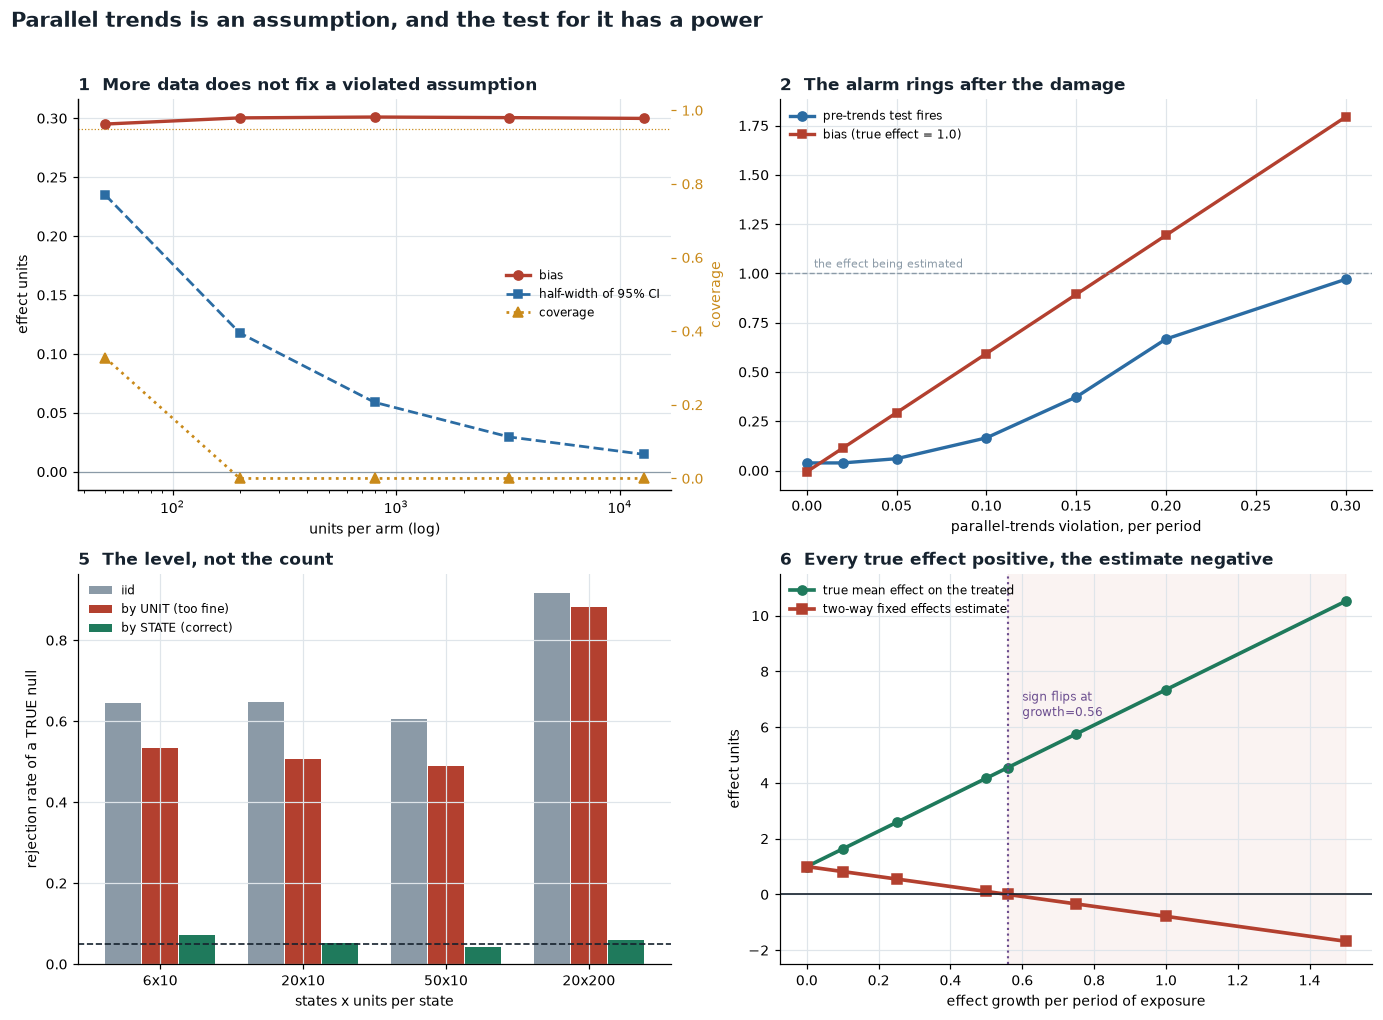

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(12.6, 9.4))
fig.patch.set_facecolor("white")

# (a) more data does not help
a = ax[0, 0]
n = [r[0] for r in rows]
a.plot(n, [r[2] for r in rows], "o-", color=BAD, lw=2.2, ms=6, label="bias")
a.plot(n, [1.96 * r[3] for r in rows], "s--", color=COOL, lw=1.8, ms=5, label="half-width of 95% CI")
a.set_xscale("log"); a.axhline(0, color=MUTE, lw=0.8)
a2 = a.twinx(); a2.plot(n, [r[4] for r in rows], "^:", color=WARN, lw=1.8, ms=6, label="coverage")
a2.set_ylim(-0.03, 1.03); a2.set_ylabel("coverage", color=WARN); a2.tick_params(colors=WARN)
a2.axhline(0.95, color=WARN, lw=0.8, ls=":"); a2.grid(False)
a.set_xlabel("units per arm (log)"); a.set_ylabel("effect units")
h1, l1 = a.get_legend_handles_labels(); h2, l2 = a2.get_legend_handles_labels()
a.legend(h1 + h2, l1 + l2, fontsize=7.6, frameon=False, loc="center right")
a.set_title("1  More data does not fix a violated assumption", fontweight="bold", loc="left", color=INK)

# (b) the pre-trends scissors
b_ = ax[0, 1]
b_.plot([r["delta"] for r in S], [r["power"] for r in S], "o-", color=COOL, lw=2.2, ms=6,
        label="pre-trends test fires")
b_.plot([r["delta"] for r in S], [r["bias"] for r in S], "s-", color=BAD, lw=2.2, ms=5,
        label="bias (true effect = 1.0)")
b_.axhline(1.0, color=MUTE, lw=0.9, ls="--")
b_.text(0.004, 1.03, "the effect being estimated", fontsize=7.4, color=MUTE)
b_.set_xlabel("parallel-trends violation, per period")
b_.legend(fontsize=7.6, frameon=False, loc="upper left")
b_.set_title("2  The alarm rings after the damage", fontweight="bold", loc="left", color=INK)

# (c) clustering level
c_ = ax[1, 0]
keys = list(s5.keys()); x = np.arange(len(keys))
c_.bar(x - 0.26, [s5[k]["iid"] for k in keys], 0.25, color=MUTE, label="iid")
c_.bar(x, [s5[k]["unit"] for k in keys], 0.25, color=BAD, label="by UNIT (too fine)")
c_.bar(x + 0.26, [s5[k]["state"] for k in keys], 0.25, color=GOOD, label="by STATE (correct)")
c_.axhline(0.05, color=INK, lw=1.1, ls="--")
c_.set_xticks(x); c_.set_xticklabels([f"{a_}x{b2}" for a_, b2 in keys])
c_.set_xlabel("states x units per state"); c_.set_ylabel("rejection rate of a TRUE null")
c_.legend(fontsize=7.6, frameon=False, loc="upper left")
c_.set_title("5  The level, not the count", fontweight="bold", loc="left", color=INK)

# (d) the sign flip
d_ = ax[1, 1]
d_.plot([g[0] for g in GROW], [g[1] for g in GROW], "o-", color=GOOD, lw=2.4, ms=6,
        label="true mean effect on the treated")
d_.plot([g[0] for g in GROW], [g[2] for g in GROW], "s-", color=BAD, lw=2.4, ms=6,
        label="two-way fixed effects estimate")
d_.axhline(0, color=INK, lw=1.1); d_.axvline(FLIP, color=PLUM, lw=1.4, ls=":")
d_.fill_between([FLIP, 1.5], -3, 12, color=BAD, alpha=0.06)
d_.text(FLIP + 0.04, 6.4, f"sign flips at\ngrowth={FLIP:.2f}", fontsize=7.6, color=PLUM)
d_.set_ylim(-2.5, 11.5); d_.set_xlabel("effect growth per period of exposure")
d_.set_ylabel("effect units"); d_.legend(fontsize=7.6, frameon=False, loc="upper left")
d_.set_title("6  Every true effect positive, the estimate negative", fontweight="bold",
             loc="left", color=INK)

fig.suptitle("Parallel trends is an assumption, and the test for it has a power",
             fontsize=14, fontweight="bold", color=INK, x=0.007, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.965))
fig.savefig("did_notebook_figure.png", dpi=140, facecolor="white")
plt.show()

## Step 9 — levels or logs is part of the assumption, and this one *is* testable

DiD is not invariant to a monotone transform. "Parallel trends" names a **different**
assumption in levels than in logs, and with unequal baselines the two cannot both hold
unless the control group does not move:

$$\text{both hold} \iff (Y_{T,0} - Y_{C,0})\left(\tfrac{Y_{C,1}}{Y_{C,0}} - 1\right) = 0$$

Two worlds. In **A** the common trend is multiplicative, so logs are correct and the true
effect is −5%. In **B** the common trend is additive, so levels are correct and the true
effect is +10 units. Each world's effect is reported accurately by its own scale and with
the **wrong sign** by the other.

In [12]:
n, T, t0 = 400, 8, 4
treated = np.zeros(n, dtype=bool); treated[: n // 2] = True
base = np.where(treated, 200.0, 100.0)[:, None]
tt = np.arange(T)[None, :]
tp = treated[:, None] * (tt >= t0)
adopt8 = np.where(treated, float(t0), np.inf)
ev8 = [e for e in (-3, -2, -1, 0, 1, 2, 3) if e != -1]
cols8 = event_dummies(adopt8, T, ev8)
lead8 = [i for i, e in enumerate(ev8) if e < 0]

print(f"{'world':>36} {'true':>6} {'levels neg':>11} {'logs neg':>9} {'clash':>7} {'pre: lv':>8} {'pre: lg':>8}")
for name, mult in (("A: multiplicative trend (logs true)", True),
                   ("B: additive trend (levels true)", False)):
    rng = np.random.default_rng(31 if mult else 32)
    reps = 600
    lv_n = lg_n = clash = f_lv = f_lg = 0
    for _ in range(reps):
        Y = (base * (1.05 ** tt) * (1 - 0.05 * tp)) if mult else (base + 5.0 * tt + 10.0 * tp)
        Y = np.clip(Y + rng.normal(0, 4.0, (n, T)), 1.0, None)
        lv = did_2x2(Y, treated, range(t0), range(t0, T))
        lg = did_2x2(np.log(Y), treated, range(t0), range(t0, T))
        lv_n += lv < 0; lg_n += lg < 0; clash += (lv < 0) != (lg < 0)
        bl, Vl, _ = fe_ols(Y, cols8);            f_lv += wald(bl, Vl, lead8) < 0.05
        bg, Vg, _ = fe_ols(np.log(Y), cols8);    f_lg += wald(bg, Vg, lead8) < 0.05
    print(f"{name:>36} {'-' if mult else '+':>6} {lv_n/reps:11.3f} {lg_n/reps:9.3f} "
          f"{clash/reps:7.3f} {f_lv/reps:8.3f} {f_lg/reps:8.3f}")

print("""
The last two columns are the constructive half. A wrong scale IS a parallel-trends
violation, so - unlike the assumption itself - it leaves a footprint in the pre-period
whenever the common trend moves during it. Run the pre-trends test on Y and on log Y;
the scale that PASSES its own test is the scale the data supports. One extra line of code.

Caveat with teeth: it works because the common trend moves before treatment. On a flat
pre-period both scales pass, both stay defensible, and the sign of the reported effect is
a choice the analyst makes rather than a thing the data settles.""")

                               world   true  levels neg  logs neg   clash  pre: lv  pre: lg
 A: multiplicative trend (logs true)      -       0.000     1.000   1.000    1.000    0.035
     B: additive trend (levels true)      +       0.000     1.000   1.000    0.037    0.998

The last two columns are the constructive half. A wrong scale IS a parallel-trends
violation, so - unlike the assumption itself - it leaves a footprint in the pre-period
whenever the common trend moves during it. Run the pre-trends test on Y and on log Y;
the scale that PASSES its own test is the scale the data supports. One extra line of code.

Caveat with teeth: it works because the common trend moves before treatment. On a flat
pre-period both scales pass, both stay defensible, and the sign of the reported effect is
a choice the analyst makes rather than a thing the data settles.


## What to put in the report

A DiD result is not "the coefficient and its stars". Five things make it auditable, and
each of them is a number this notebook computed:

1. **The pre-window length**, and the smallest violation the pre-trends test could have
   caught at that length. Five pre-periods rules out almost nothing.
2. **The bias the smallest undetectable violation would imply**, in the units of the
   reported effect. Not a p-value — a bias.
3. **What the standard error is clustered by**, and why that is the level at which
   treatment varies. Six clusters at the right level beat fifty at the wrong one.
4. **For staggered adoption:** the share of negative weight, the heterogeneity `sd` at
   which the estimate would be zero, and the not-yet-treated estimate printed next to the
   TWFE one.
5. **The scale**, levels or logs, argued for *before* the regression — and its pre-trends
   test run in both.

The through-line: every one of these failures is a property of the **design**, computable
from the adoption dates and the panel shape before the outcome column is ever opened. The
regression output is the last place any of them shows up, and mostly it does not show up
there at all.

## Try your own

Uncomment and edit. The two most instructive knobs are `diff_trend` in `make_panel` (how
badly parallel trends fails) and `growth` in `make_staggered` (how much the effect
strengthens with exposure).

In [13]:
# --- 1. How bad is the violation MY pre-window could hide?
# MY_PRE_PERIODS = 6      # how many pre-periods you actually observe
# MY_N_PER_ARM   = 500    # units per arm
# for d in (0.02, 0.05, 0.10, 0.20):
#     p = power_npre(MY_PRE_PERIODS, n_arm=MY_N_PER_ARM, delta=d, reps=400)
#     print(f"delta {d:.2f}: test fires {p:.3f} of the time, bias would be {d * MY_PRE_PERIODS:.3f}")

# --- 2. Does MY staggered design put negative weight anywhere?
# MY_COHORTS = [(3, 40), (7, 40), (12, 40)]   # (adoption period, number of units)
# MY_T       = 18
# MY_NEVER   = 0                               # never-treated units
# Ym, Dm, am, tm = make_staggered(np.random.default_rng(0), MY_COHORTS, T=MY_T,
#                                 n_never=MY_NEVER, growth=0.4, sigma=0.0, unit_sd=0.0)
# Wm = twfe_cell_weights(Dm); wm = Wm[Dm > 0]
# print(f"negative-weight cells: {(wm < 0).mean():.1%}, total {wm[wm < 0].sum():+.4f}")
# print(f"true mean effect {tm[Dm > 0].mean():.4f}   TWFE {twfe(Ym, Dm):.4f}")
# if MY_NEVER: print(f"not-yet-treated ATT {aggregate_att(group_time_att(Ym, am), am):.4f}")

# --- 3. What heterogeneity would zero out MY estimate?  (no outcome data needed)
# wm = twfe_cell_weights(Dm)[Dm > 0]
# ratio = abs(1.0) * wm.std(ddof=0) / abs(wm.mean() - (wm * wm).sum())
# print(f"this design tolerates heterogeneity up to {ratio:.3f}x its own ATT")

# --- 4. Is my outcome a levels story or a logs story?
# MY_Y = ...   # (N, T) array, treated units first
# for scale, Z in (("levels", MY_Y), ("logs", np.log(MY_Y))):
#     bz, Vz, _ = fe_ols(Z, cols8)
#     print(f"{scale:>7}: pre-trends p = {wald(bz, Vz, lead8):.4f}")

---

**Day 167 of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** — one small, real tool a day.

Fourth build in experimentation and causal inference, after
[`peeking-cost`](../peeking-cost/) (when you look),
[`srm-detector`](../srm-detector/) (who ended up in which arm) and
[`cuped-variance`](../cuped-variance/) (needing fewer users). Those three all assumed
randomisation held. This is the first one that does not.

**The full build:**
- `python evidence.py` — the eight-section measurement, ~70s
- `python -m pytest test_did.py` — 45 assertions behind every number
- `streamlit run app.py` — drive the design and watch what it can and cannot see
- `python make_chart.py` — the six-panel figure

**Reading, for the results this build re-derives rather than cites:** Bertrand, Duflo &
Mullainathan (2004) on serial correlation; Roth (2022) on pre-testing;
Goodman-Bacon (2021) and de Chaisemartin & D'Haultfœuille (2020) on TWFE weights;
Callaway & Sant'Anna (2021) on group-time ATT.